# Learning SDEs with Volterra signatures


## Volterra signature learning

In this notebook we illustrate how Volterra signatures can be used as features for learning solution maps of stochastic Volterra equations.

We consider solution maps to stochastic Volterra equation, that is

$$
X \longmapsto Y_t, \qquad Y_t=Y_0 + \int_0^tK(t,s)\sigma(Y_s)\mathrm{d}X_s
$$
The Volterra signature $\mathrm{VSig}(X;K)$ provides a feature representation adapted to this situation. 
$
The goal of this notebook is to test this idea on synthetic data. We generate sample paths of a Volterra SDE and learn the solution map from the driving noise using different feature representations. In particular, we compare classical signatures with Volterra signatures and investigate the benefit of including the Volterra kernel structure.

First install `tensordev`, which provides the algorithms used below for computing Volterra signatures:

```bash
pip install tensordev

In [2]:
!pip install tensordev

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Step 1: Compute Volterra signature of driving Brownian motion


In [24]:
import time
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp

from tensordev import VolterraSignature


# ============================================================
# Generate paths, fixed seed
# ============================================================

seed = 0
rng = np.random.default_rng(seed)

T = 2.0
M = 1000
N = int(T * 500)

tt = np.linspace(0.0, T, N + 1)
dt = tt[1] - tt[0]

# Brownian increments
dW = np.sqrt(dt) * rng.normal(size=(M, N))

# Time increments are deterministic
dT = dt * np.ones((M, N))

# Increment input: shape (M, N, 2)
# channel 0 = time increment, channel 1 = Brownian increment
dX = np.stack([dT, dW], axis=-1)


# ============================================================
# TensorDev Volterra signature object
# ============================================================

siglevel = 6
beta = 1.1
dtype = jnp.float64

A = jnp.eye(2, dtype=dtype)[None, :, :]

vsig_frac = VolterraSignature.fractional(
    trunc=int(siglevel),
    beta=jnp.array([beta], dtype=dtype),
    A=A,
)


# ============================================================
# Jitted full stream computation for one batch
# ============================================================

@jax.jit
def compute_vsig_stream_batch(dX_batch):
    return vsig_frac.vsig(
        dX_batch,
        dt=float(dt),
        block_size=1,
        order=0,
        scheme="fft",
        output_starting_point=True,
        increment_input=True,
    )


# ============================================================
# Batched computation
# ============================================================

#if little memory is available, lower batches can help to increase speed
batch_size = 1000
num_batches = int(np.ceil(M / batch_size))

level_chunks = None

t_total_0 = time.time()

for b in range(num_batches):
    start = b * batch_size
    stop = min((b + 1) * batch_size, M)

    print(f"Batch {b + 1}/{num_batches}: paths {start}:{stop}")

    dX_batch = jax.device_put(jnp.asarray(dX[start:stop], dtype=dtype))

    t0 = time.time()

    out_batch = compute_vsig_stream_batch(dX_batch)
    # Force computation before timing and before moving to host
    out_batch = jax.tree_util.tree_map(
        lambda x: x.block_until_ready(),
        out_batch,
    )

    t1 = time.time()

    
    out_batch_np = tuple(np.asarray(level) for level in out_batch)

    if level_chunks is None:
        level_chunks = [[] for _ in out_batch_np]

    for ell, level_arr in enumerate(out_batch_np):
        level_chunks[ell].append(level_arr)


# Concatenate batches along sample axis
Vsig_frac_td_stream = tuple(
    np.concatenate(chunks, axis=0)
    for chunks in level_chunks
)

t_total_1 = time.time()

print(f"\nTotal batched computation time: {t_total_1 - t_total_0:.3f} seconds")

Batch 1/1: paths 0:1000

Total batched computation time: 15.059 seconds


In [25]:
#compute standard signature for comparison
import iisignature as ii
# Brownian path nodes
W = np.concatenate(
    [np.zeros((M, 1)), np.cumsum(dW, axis=1)],
    axis=1,
)

# Time channel repeated for all samples
tt_batch = np.broadcast_to(tt[None, :], (M, N + 1))

# Path nodes: shape (M, N+1, 2)
# channel 0 = time, channel 1 = Brownian motion
W_augmented = np.stack([tt_batch, W], axis=-1)

# Increment input for Volterra signature
dX = W_augmented[:, 1:, :] - W_augmented[:, :-1, :]
Sig = np.zeros((M,N+1, ii.siglength(W_augmented.shape[-1], siglevel)+1))
Sig[:,:,0] = 1
Sig[:,0,1:] = 0
Sig[:,1:,1:] = ii.sig(W_augmented[:,:,:], siglevel, 2)

# Step 2: Generate sample of linear Volterra SDE solution

In [26]:
#Computing the Volterra SDE solution using Euler (very inefficient, but only serves as benchmark solution)
from scipy.special import gamma
import numpy as np

# ============================================================
# Fractional Volterra SDE generation using existing data
# Uses the already generated:
#   tt, dt, dW, M, N, beta
# ============================================================

def frac_kernel(t, s, beta):
    if t <= s:
        return 0.0
    return (t - s) ** (beta - 1.0) / gamma(beta)


# SDE parameters
x0 = 1.0

a = 1.0
b = 0.5

h = 0.0
f = -0.5

# X_t = x0 + ∫_0^t K(t,s) [(h + f X_s) ds + (a + b X_s) dW_s]
X_sde = x0 * np.ones((M, N + 1), dtype=float)

# Precompute fractional kernel weights:
# K_weights[i,j] = K(t_{i+1}, t_j), j <= i
K_weights = np.zeros((N, N), dtype=float)

for i in range(N):
    t_ip1 = tt[i + 1]
    for j in range(i + 1):
        K_weights[i, j] = frac_kernel(t_ip1, tt[j], beta=beta)

# Sequential Euler-type Volterra scheme
for i in range(N):
    K_i = K_weights[i, : i + 1]  # shape (i+1,)

    drift_part = (h + f * X_sde[:, : i + 1]) * dt
    diff_part = (a + b * X_sde[:, : i + 1]) * dW[:, : i + 1]

    X_sde[:, i + 1] = x0 + np.sum(
        K_i[None, :] * (drift_part + diff_part),
        axis=1,
    )

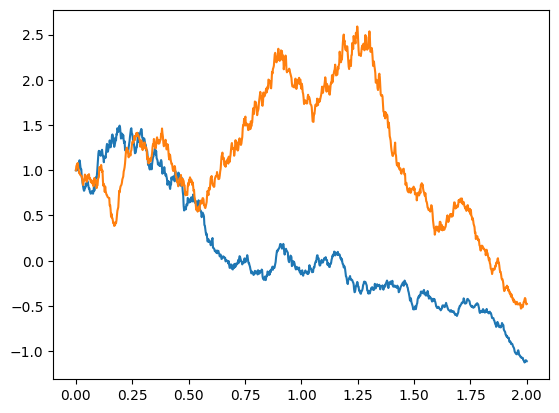

In [27]:
import matplotlib.pyplot as plt
plt.plot(tt,X_sde[0,:])
plt.plot(tt,X_sde[1,:])

# Step 3: Perform regression on Sig and VSig

In [28]:
# Performing Regression with both VSig and classical Sig

import numpy as np

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score


N_training = int(N / 2)
# If you used the Brownian/time driver:
Vsig_frac = np.concatenate(
    [
        np.asarray(level).reshape(level.shape[0], level.shape[1], -1)
        for level in Vsig_frac_td_stream
    ],
    axis=-1,
)


# Choose features
Psi = Vsig_frac          # shape (M, N+1, d_vsig)
Psi_cl = Sig             # shape (M, N+1, d_sig)

# Choose target
# If you generated the SDE as X_sde, use X_sde.
# If your target is still called X, use X.
Y = X_sde                # shape (M, N+1)

Psi = np.asarray(Psi)
Psi_cl = np.asarray(Psi_cl)
Y = np.asarray(Y)

print("Psi shape   :", Psi.shape)
print("Sig shape   :", Psi_cl.shape)
print("Y shape     :", Y.shape)

_, _, d_vsig = Psi.shape
_, _, d_sig = Psi_cl.shape

idx = np.arange(M)

idx_tr, idx_te = train_test_split(
    idx,
    test_size=0.1,
    random_state=0,
    shuffle=True,
)

Psi_tr = Psi[idx_tr, 0:N_training]
Psi_te = Psi[idx_te]

Psi_tr_cl = Psi_cl[idx_tr, 0:N_training]
Psi_te_cl = Psi_cl[idx_te]

Y_tr = Y[idx_tr, 0:N_training]
Y_te = Y[idx_te]

X_tr = Psi_tr.reshape(-1, d_vsig)
X_tr_cl = Psi_tr_cl.reshape(-1, d_sig)
y_tr = Y_tr.reshape(-1)

X_te_t1 = Psi_te[:, 0:N_training].reshape(-1, d_vsig)
X_te_cl_t1 = Psi_te_cl[:, 0:N_training].reshape(-1, d_sig)
y_te_t1 = Y_te[:, 0:N_training].reshape(-1)

X_te_full = Psi_te.reshape(-1, d_vsig)
X_te_cl_full = Psi_te_cl.reshape(-1, d_sig)
y_te_full = Y_te.reshape(-1)

alphas = np.logspace(-8, 2, 30)

groups_tr = np.repeat(np.arange(len(idx_tr)), N_training)

cv = GroupKFold(n_splits=5)

gs = GridSearchCV(
    Ridge(fit_intercept=False),
    param_grid={"alpha": alphas},
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

gs.fit(X_tr, y_tr, groups=groups_tr)

model = gs.best_estimator_
print("chosen alpha for VSig:", model.alpha)


gs_1 = GridSearchCV(
    Ridge(fit_intercept=False),
    param_grid={"alpha": alphas},
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

gs_1.fit(X_tr_cl, y_tr, groups=groups_tr)

model_cl = gs_1.best_estimator_
print("chosen alpha for Sig:", model_cl.alpha)


y_hat_te_t1 = model.predict(X_te_t1)
y_hat_te_full = model.predict(X_te_full)

y_hat_te_t1_cl = model_cl.predict(X_te_cl_t1)
y_hat_te_full_cl = model_cl.predict(X_te_full)


V_expansion_te = np.tensordot(Psi_te, model.coef_, axes=([2], [0]))
Sig_expansion_te = np.tensordot(Psi_te_cl, model_cl.coef_, axes=([2], [0]))


print("\nVSig metrics")
print("test t<=training MSE:", mean_squared_error(y_te_t1, y_hat_te_t1))
print("test t<=training R2 :", r2_score(y_te_t1, y_hat_te_t1))
print("test full MSE       :", mean_squared_error(y_te_full, y_hat_te_full))
print("test full R2        :", r2_score(y_te_full, y_hat_te_full))

print("\nSig metrics")
print("test t<=training MSE:", mean_squared_error(y_te_t1, y_hat_te_t1_cl))
print("test t<=training R2 :", r2_score(y_te_t1, y_hat_te_t1_cl))
print("test full MSE       :", mean_squared_error(y_te_full, y_hat_te_full_cl))
print("test full R2        :", r2_score(y_te_full, y_hat_te_full_cl))

print("\nExpansion shapes")
print("V_expansion_te  :", V_expansion_te.shape)
print("Sig_expansion_te:", Sig_expansion_te.shape)
print("Y_te            :", Y_te.shape)

Psi shape   : (1000, 1001, 127)
Sig shape   : (1000, 1001, 127)
Y shape     : (1000, 1001)
chosen alpha for VSig: 0.1743328822199991
chosen alpha for Sig: 1e-08

VSig metrics
test t<=training MSE: 6.300213173026972e-05
test t<=training R2 : 0.9999093044705601
test full MSE       : 0.0012176054096656656
test full R2        : 0.9992034251790429

Sig metrics
test t<=training MSE: 0.00022905705288906787
test t<=training R2 : 0.9996702579720215
test full MSE       : 2.938657867695042
test full R2        : -0.9225118796540805

Expansion shapes
V_expansion_te  : (100, 1001)
Sig_expansion_te: (100, 1001)
Y_te            : (100, 1001)


In [29]:
print("chosen alpha for VSIG:", model.alpha)
print("chosen alpha for SIG:", model_cl.alpha)
print("test MSE VSIG training regime:", mean_squared_error(y_hat_te_t1, y_te_t1))
print("test R2 VSIG training regime :", r2_score(y_te_t1, y_hat_te_t1))
print("test MSE VSIG full interval:", mean_squared_error(y_hat_te_full, y_te_full))
print("test R2 VSIG full interval:", r2_score(y_te_full, y_hat_te_full))
print("test MSE SIG training regime:", mean_squared_error(y_te_t1, y_hat_te_t1_cl))
print("test R2 SIG training regime:", r2_score(y_te_t1, y_hat_te_t1_cl))
print("test MSE SIG full interval:", mean_squared_error(y_te_full, y_hat_te_full_cl))
print("test R2 SIG full interval:", r2_score(y_te_full, y_hat_te_full_cl))

chosen alpha for VSIG: 0.1743328822199991
chosen alpha for SIG: 1e-08
test MSE VSIG training regime: 6.300213173026972e-05
test R2 VSIG training regime : 0.9999093044705601
test MSE VSIG full interval: 0.0012176054096656656
test R2 VSIG full interval: 0.9992034251790429
test MSE SIG training regime: 0.00022905705288906787
test R2 SIG training regime: 0.9996702579720215
test MSE SIG full interval: 2.938657867695042
test R2 SIG full interval: -0.9225118796540805


# Step 4: additionally fit scalar exponential VSig

In [30]:
# ============================================================
# Exponential VSig with R=1 FSSK, CV over lambda and ridge alpha
# ============================================================

import time
import numpy as np

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from tensordev.sss.state import StateSpaceSignature


# ============================================================
# Basic settings
# ============================================================

dtype = jnp.float64

N_training = int(N / 2)

Y = X_sde   # target process, shape (M, N+1)

if "idx_tr" not in globals() or "idx_te" not in globals():
    idx = np.arange(M)
    idx_tr, idx_te = train_test_split(
        idx,
        test_size=0.1,
        random_state=0,
        shuffle=True,
    )

lambda_values = np.linspace(0.0, 5.0, 10)
ridge_alphas = np.logspace(-8, 2, 30)


# ============================================================
# Validation split inside training set
# ============================================================

idx_fit, idx_val = train_test_split(
    idx_tr,
    test_size=0.2,
    random_state=1,
    shuffle=True,
)

y_fit = Y[idx_fit, :N_training].reshape(-1)
y_val = Y[idx_val, :N_training].reshape(-1)

groups_fit = np.repeat(np.arange(len(idx_fit)), N_training)
cv_fit = GroupKFold(n_splits=5)

best_err = np.inf
best_lambd = None
best_alpha = None
best_model_local = None


# ============================================================
# Input path restricted to training horizon
# ============================================================

X_horizon = jnp.asarray(W_augmented[:, :N_training, :], dtype=dtype)

# Correct R=1 FSSK shape:
# Lambda shape: (R,R) = (1,1)
# A shape     : (q,m,path_dim) = (1,2,2)
# b shape     : (q,R) = (1,1)
#
# This gives path_dim=2, matching W_augmented.shape[-1].
A_exp = jnp.eye(2, dtype=dtype)[None, :, :]   # (1, 2, 2)
b_exp = jnp.ones((1, 1), dtype=dtype)         # (1, 1)

print("X_horizon shape:", X_horizon.shape)
print("A_exp shape    :", A_exp.shape)
print("b_exp shape    :", b_exp.shape)


# ============================================================
# CV over lambda
# ============================================================

for lambd in lambda_values:
    s = time.time()

    Lambda_exp = jnp.array([[float(lambd)]], dtype=dtype)

    exp_sig = StateSpaceSignature.from_matrix(
        trunc=int(siglevel),
        Lambda=Lambda_exp,
        A=A_exp,
        b=b_exp,
        quad_order=32,
    )

    print("kernel.path_dim:", exp_sig.kernel.path_dim)

    levels_exp = exp_sig.vsig(
        X_horizon,
        dt=float(dt),
        axis=1,
        block_size=1,
        accumulate=True,
        output_starting_state=True,
        increment_input=False,
    )

    SSig_exp = np.concatenate(
        [
            np.asarray(level).reshape(
                np.asarray(level).shape[0],
                np.asarray(level).shape[1],
                -1,
            )
            for level in levels_exp
        ],
        axis=-1,
    )

    d_exp = SSig_exp.shape[-1]

    Sig_fit = SSig_exp[idx_fit].reshape(-1, d_exp)
    Sig_val = SSig_exp[idx_val].reshape(-1, d_exp)

    gs_exp = GridSearchCV(
        Ridge(fit_intercept=False),
        param_grid={"alpha": ridge_alphas},
        cv=cv_fit,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    gs_exp.fit(Sig_fit, y_fit, groups=groups_fit)

    pred_val = gs_exp.best_estimator_.predict(Sig_val)
    err_val = mean_squared_error(y_val, pred_val)

    print(
        f"lambda={lambd:.4g} | "
        f"val MSE={err_val:.6g} | "
        f"best ridge alpha={gs_exp.best_estimator_.alpha:.4g} | "
        f"time={time.time() - s:.2f}s"
    )

    if err_val < best_err:
        best_err = float(err_val)
        best_lambd = float(lambd)
        best_alpha = float(gs_exp.best_estimator_.alpha)
        best_model_local = gs_exp.best_estimator_


print("\nbest lambda:", best_lambd)
print("best ridge alpha:", best_alpha)
print("best validation MSE:", best_err)


# ============================================================
# Recompute exponential VSig on full horizon with best lambda
# ============================================================

X_full = jnp.asarray(W_augmented, dtype=dtype)

Lambda_exp_best = jnp.array([[float(best_lambd)]], dtype=dtype)

exp_sig_best = StateSpaceSignature.from_matrix(
    trunc=int(siglevel),
    Lambda=Lambda_exp_best,
    A=A_exp,
    b=b_exp,
    quad_order=32,
)

levels_exp_full = exp_sig_best.vsig(
    X_full,
    dt=float(dt),
    axis=1,
    block_size=1,
    accumulate=True,
    output_starting_state=True,
    increment_input=False,
)

Vsig_exp = np.concatenate(
    [
        np.asarray(level).reshape(
            np.asarray(level).shape[0],
            np.asarray(level).shape[1],
            -1,
        )
        for level in levels_exp_full
    ],
    axis=-1,
)

print("\nVsig_exp shape:", Vsig_exp.shape)


# ============================================================
# Final ridge fit on full training paths with best lambda
# ============================================================

_, _, d_exp = Vsig_exp.shape

Psi_exp_tr = Vsig_exp[idx_tr, :N_training]
Psi_exp_te = Vsig_exp[idx_te]

Y_tr = Y[idx_tr, :N_training]
Y_te = Y[idx_te]

X_exp_tr = Psi_exp_tr.reshape(-1, d_exp)
y_tr = Y_tr.reshape(-1)

groups_tr = np.repeat(np.arange(len(idx_tr)), N_training)
cv_tr = GroupKFold(n_splits=5)

gs_exp_final = GridSearchCV(
    Ridge(fit_intercept=False),
    param_grid={"alpha": ridge_alphas},
    cv=cv_tr,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

gs_exp_final.fit(X_exp_tr, y_tr, groups=groups_tr)

model_exp = gs_exp_final.best_estimator_

print("final chosen alpha for exponential VSig:", model_exp.alpha)


# ============================================================
# Predictions and metrics
# ============================================================

X_exp_te_t1 = Psi_exp_te[:, :N_training].reshape(-1, d_exp)
y_te_t1 = Y_te[:, :N_training].reshape(-1)

X_exp_te_full = Psi_exp_te.reshape(-1, d_exp)
y_te_full = Y_te.reshape(-1)

y_hat_exp_te_t1 = model_exp.predict(X_exp_te_t1)
y_hat_exp_te_full = model_exp.predict(X_exp_te_full)

ExpV_expansion_te = np.tensordot(
    Psi_exp_te,
    model_exp.coef_,
    axes=([2], [0]),
)

print("\nExponential VSig metrics")
print("test t<=training MSE:", mean_squared_error(y_te_t1, y_hat_exp_te_t1))
print("test t<=training R2 :", r2_score(y_te_t1, y_hat_exp_te_t1))
print("test full MSE       :", mean_squared_error(y_te_full, y_hat_exp_te_full))
print("test full R2        :", r2_score(y_te_full, y_hat_exp_te_full))

print("\nExpV_expansion_te shape:", ExpV_expansion_te.shape)

X_horizon shape: (1000, 500, 2)
A_exp shape    : (1, 2, 2)
b_exp shape    : (1, 1)
kernel.path_dim: 2
lambda=0 | val MSE=0.000219744 | best ridge alpha=1e-08 | time=4.48s
kernel.path_dim: 2
lambda=0.5556 | val MSE=0.000200949 | best ridge alpha=1e-08 | time=3.71s
kernel.path_dim: 2
lambda=1.111 | val MSE=0.000184968 | best ridge alpha=1e-08 | time=3.81s
kernel.path_dim: 2
lambda=1.667 | val MSE=0.000171438 | best ridge alpha=1e-08 | time=3.78s
kernel.path_dim: 2
lambda=2.222 | val MSE=0.000160001 | best ridge alpha=1e-08 | time=3.69s
kernel.path_dim: 2
lambda=2.778 | val MSE=0.00015027 | best ridge alpha=1e-08 | time=3.78s
kernel.path_dim: 2
lambda=3.333 | val MSE=0.000141912 | best ridge alpha=1e-08 | time=3.75s
kernel.path_dim: 2
lambda=3.889 | val MSE=0.000134982 | best ridge alpha=1e-08 | time=3.71s
kernel.path_dim: 2
lambda=4.444 | val MSE=0.000130858 | best ridge alpha=1e-08 | time=3.66s
kernel.path_dim: 2
lambda=5 | val MSE=0.000134582 | best ridge alpha=1e-08 | time=3.76s

best

In [31]:
# ============================================================
# Fit final exponential VSig model with best_lambd and best_alpha
# TensorDev / FSSK version
# ============================================================

import numpy as np

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

from tensordev import StateSpaceSignature


# ============================================================
# Compute exponential VSig on full horizon with best_lambd
# ============================================================

dtype = jnp.float64

YYY = W_augmented[:, :, :]

X_full = jnp.asarray(YYY, dtype=dtype)

Lambda_exp_best = jnp.array([[float(best_lambd)]], dtype=dtype)

# Same convention as before:
# path_dim = 2, R = 1
A_exp = jnp.eye(2, dtype=dtype)[None, :, :]   # shape (1, 2, 2)
b_exp = jnp.ones((1, 1), dtype=dtype)         # shape (1, 1)

exp_sig_best = StateSpaceSignature.from_matrix(
    trunc=int(siglevel),
    Lambda=Lambda_exp_best,
    A=A_exp,
    b=b_exp,
    quad_order=32,
)

print("kernel.path_dim:", exp_sig_best.kernel.path_dim)

levels_exp_full = exp_sig_best.vsig(
    X_full,
    dt=float(dt),
    axis=1,
    block_size=1,
    accumulate=True,
    output_starting_state=True,
    increment_input=False,
)

Psi_exp = np.concatenate(
    [
        np.asarray(level).reshape(
            np.asarray(level).shape[0],
            np.asarray(level).shape[1],
            -1,
        )
        for level in levels_exp_full
    ],
    axis=-1,
)

print("Psi_exp shape:", Psi_exp.shape)


# ============================================================
# Prepare train/test design matrices
# ============================================================

Y = X_sde

_, _, d_exp = Psi_exp.shape

Psi_exp_tr = Psi_exp[idx_tr, 0:N_training]
Psi_exp_te = Psi_exp[idx_te]

Y_tr = Y[idx_tr, 0:N_training]
Y_te = Y[idx_te]

X_exp_tr = Psi_exp_tr.reshape(-1, d_exp)
y_tr = Y_tr.reshape(-1)

X_exp_te_t1 = Psi_exp_te[:, 0:N_training].reshape(-1, d_exp)
X_exp_te_full = Psi_exp_te.reshape(-1, d_exp)

y_te_t1 = Y_te[:, 0:N_training].reshape(-1)
y_te_full = Y_te.reshape(-1)


# ============================================================
# Fit with best_alpha
# ============================================================

model_exp = Ridge(
    alpha=float(best_alpha),
    fit_intercept=False,
)

model_exp.fit(X_exp_tr, y_tr)


# ============================================================
# Predict
# ============================================================

y_hat_te_exp_t1 = model_exp.predict(X_exp_te_t1)
y_hat_te_exp_full = model_exp.predict(X_exp_te_full)

ExpV_expansion_te = np.tensordot(
    Psi_exp_te,
    model_exp.coef_,
    axes=([2], [0]),
)


# ============================================================
# Metrics
# ============================================================

print("\nExponential VSig final fit")
print("best_lambd:", best_lambd)
print("best_alpha:", best_alpha)

print("\nt <= training horizon")
print("MSE:", mean_squared_error(y_te_t1, y_hat_te_exp_t1))
print("R2 :", r2_score(y_te_t1, y_hat_te_exp_t1))

print("\nfull test horizon")
print("MSE:", mean_squared_error(y_te_full, y_hat_te_exp_full))
print("R2 :", r2_score(y_te_full, y_hat_te_exp_full))

print("\nExpansion shape:", ExpV_expansion_te.shape)

kernel.path_dim: 2
Psi_exp shape: (1000, 1001, 127)

Exponential VSig final fit
best_lambd: 4.444444444444445
best_alpha: 1e-08

t <= training horizon
MSE: 0.00013758396075723726
R2 : 0.99980193923887

full test horizon
MSE: 0.012425998989017287
R2 : 0.9918707342778583

Expansion shape: (100, 1001)


## Step 5: Plot results and create table


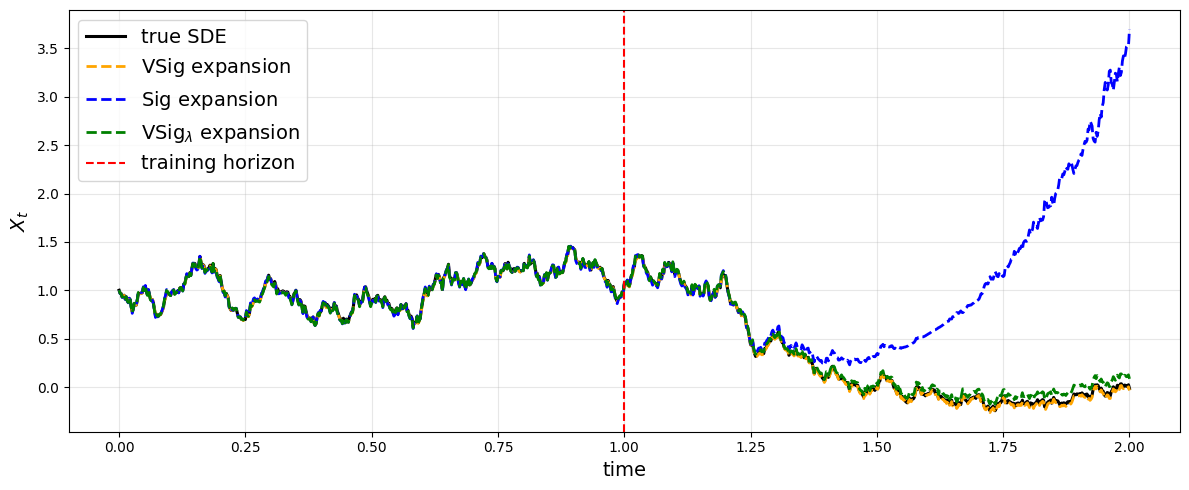

In [32]:
import numpy as np
import matplotlib.pyplot as plt

i = 13
k_vol = 1   # downsampling for VSig
k_lin = 1   # downsampling for Sig
k_exp = 1   # downsampling for exponential VSig

fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

# true path
ax.plot(
    tt,
    Y_te[i, :],
    color="black",
    lw=2.2,
    ls="-",
    label="true SDE",
)

# VSig expansion
ax.plot(
    tt[::k_vol],
    V_expansion_te[i, ::k_vol],
    color="orange",
    linestyle="--",
    linewidth=2,
    label=r"$\mathrm{VSig}$ expansion",
)

# classical signature expansion
ax.plot(
    tt[::k_lin],
    Sig_expansion_te[i, ::k_lin],
    color="blue",
    linestyle="--",
    linewidth=2,
    label=r"$\mathrm{Sig}$ expansion",
)

# exponential Volterra signature expansion
ax.plot(
    tt[::k_exp],
    ExpV_expansion_te[i, ::k_exp],   # use ESig_expansion_te here only if that is your actual variable name
    color="green",
    linestyle="--",
    linewidth=2,
    label=r"$\mathrm{VSig}_{\lambda}$ expansion",
)

# training/test split
ax.axvline(
    x=tt[N_training],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="training horizon",
)

ax.set_xlabel("time", fontsize=14)
ax.set_ylabel(r"$X_t$", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=14)

plt.tight_layout()
plt.savefig("compare_solution_jax.pdf", bbox_inches="tight")
plt.show()


In [33]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# Metrics from current notebook variables
# ============================================================

mse_sig_t1 = mean_squared_error(y_te_t1, y_hat_te_t1_cl)
r2_sig_t1  = r2_score(y_te_t1, y_hat_te_t1_cl)

mse_sig_full = mean_squared_error(y_te_full, y_hat_te_full_cl)
r2_sig_full  = r2_score(y_te_full, y_hat_te_full_cl)


mse_vsig_t1 = mean_squared_error(y_te_t1, y_hat_te_t1)
r2_vsig_t1  = r2_score(y_te_t1, y_hat_te_t1)

mse_vsig_full = mean_squared_error(y_te_full, y_hat_te_full)
r2_vsig_full  = r2_score(y_te_full, y_hat_te_full)


mse_exp_t1 = mean_squared_error(y_te_t1, y_hat_te_exp_t1)
r2_exp_t1  = r2_score(y_te_t1, y_hat_te_exp_t1)

mse_exp_full = mean_squared_error(y_te_full, y_hat_te_exp_full)
r2_exp_full  = r2_score(y_te_full, y_hat_te_exp_full)


# ============================================================
# Formatting helpers
# ============================================================

def fmt_mse(x):
    x = float(x)
    if x == 0:
        return "$0$"
    if abs(x) < 1e-3 or abs(x) >= 1e3:
        exponent = int(np.floor(np.log10(abs(x))))
        mantissa = x / (10 ** exponent)
        return rf"${mantissa:.2f} \times 10^{{{exponent}}}$"
    return rf"${x:.4f}$"

def fmt_r2(x):
    return f"{float(x):.3f}"


# ============================================================
# Build LaTeX table
# ============================================================

t_train = tt[N_training]
t_full = tt[-1]

latex_table = rf"""
\begin{{tabular}}{{lcccc}}
\hline
Method & $\mathrm{{MSE}}\!\mid_{{[0,{t_train:g}]}}$ & $R^2\!\mid_{{[0,{t_train:g}]}}$ & $\mathrm{{MSE}}\!\mid_{{[0,{t_full:g}]}}$ & $R^2\!\mid_{{[0,{t_full:g}]}}$ \\
\hline
\texttt{{Sig}}                 & {fmt_mse(mse_sig_t1)} & {fmt_r2(r2_sig_t1)} & {fmt_mse(mse_sig_full)} & {fmt_r2(r2_sig_full)} \\
$\texttt{{VSig}}_k$            & {fmt_mse(mse_vsig_t1)} & {fmt_r2(r2_vsig_t1)} & {fmt_mse(mse_vsig_full)} & {fmt_r2(r2_vsig_full)} \\
$\texttt{{VSig}}_{{k_\lambda}}$  & {fmt_mse(mse_exp_t1)} & {fmt_r2(r2_exp_t1)} & {fmt_mse(mse_exp_full)} & {fmt_r2(r2_exp_full)} \\
\hline
\end{{tabular}}
"""

print(latex_table)


\begin{tabular}{lcccc}
\hline
Method & $\mathrm{MSE}\!\mid_{[0,1]}$ & $R^2\!\mid_{[0,1]}$ & $\mathrm{MSE}\!\mid_{[0,2]}$ & $R^2\!\mid_{[0,2]}$ \\
\hline
\texttt{Sig}                 & $2.29 \times 10^{-4}$ & 1.000 & $2.9387$ & -0.923 \\
$\texttt{VSig}_k$            & $6.30 \times 10^{-5}$ & 1.000 & $0.0012$ & 0.999 \\
$\texttt{VSig}_{k_\lambda}$  & $1.38 \times 10^{-4}$ & 1.000 & $0.0124$ & 0.992 \\
\hline
\end{tabular}

